# FEEPS sunlight contamination removal and 4SC averages of omnidirectional and Pitch-angle distributions for electrons
author: Apostolos Kolokotronis

In [10]:
%matplotlib widget

import matplotlib.pyplot as plt
import numpy as np
from pyrfu import mms
import pyrfu
from pyrfu import pyrf
from pyrfu.plot import plot_line, plot_spectr, make_labels
    
from copy import deepcopy
pyrfu.plot.set_color_cycle(pal = "pyrfu")


(['pyrfu:blue',
  'pyrfu:green',
  'pyrfu:red',
  'pyrfu:fg',
  'pyrfu:orange',
  'pyrfu:purple',
  'pyrfu:yellow',
  'pyrfu:lightblue',
  'pyrfu:olive'],
 'hot_white_desaturated')

In [11]:
mms.db_init(default="local", local="/data/mms")
tint =['2017-07-24T12:48:44.00', '2017-07-24T12:50:23.00']

[10-Feb-26 19:31:16] INFO: Updating MMS data access configuration in /homelocal/apostolosk/envs/mms_projects/lib/python3.12/site-packages/pyrfu/mms/config.json...
[10-Feb-26 19:31:16] INFO: Updating MMS SDC credentials in /homelocal/apostolosk/.config/python_keyring...


## Load FGM and FEEPS data from the four MMS spacecraft

In [12]:
b_gsm = [mms.get_data("b_gsm_fgm_brst_l2", tint, mms_id) for mms_id in range(1, 5)]
b_gsm_4sc = pyrf.avg_4sc(b_gsm)

b_bcs = [mms.get_data("b_bcs_fgm_brst_l2", tint, mms_id) for mms_id in range(1, 5)]

dpf_feeps_alle_e = [mms.get_feeps_alleyes(f"fluxe_brst_l2", tint, mms_id) for mms_id in range(1, 5)]


[10-Feb-26 19:31:17] INFO: Loading mms1_fgm_b_gsm_brst_l2...
[10-Feb-26 19:31:17] INFO: Loading mms2_fgm_b_gsm_brst_l2...
[10-Feb-26 19:31:17] INFO: Loading mms3_fgm_b_gsm_brst_l2...
[10-Feb-26 19:31:17] INFO: Loading mms4_fgm_b_gsm_brst_l2...
[10-Feb-26 19:31:17] INFO: Loading mms1_fgm_b_bcs_brst_l2...
[10-Feb-26 19:31:17] INFO: Loading mms2_fgm_b_bcs_brst_l2...
[10-Feb-26 19:31:17] INFO: Loading mms3_fgm_b_bcs_brst_l2...
[10-Feb-26 19:31:17] INFO: Loading mms4_fgm_b_bcs_brst_l2...
[10-Feb-26 19:31:17] INFO: Loading mms1_epd_feeps_brst_l2_electron_spinsectnum...
[10-Feb-26 19:31:17] INFO: Loading mms1_epd_feeps_brst_l2_electron_pitch_angle...
[10-Feb-26 19:31:17] INFO: Loading mms1_epd_feeps_brst_l2_electron_top_intensity_sensorid_1...
[10-Feb-26 19:31:17] INFO: Loading mms1_epd_feeps_brst_l2_electron_top_intensity_sensorid_2...
[10-Feb-26 19:31:17] INFO: Loading mms1_epd_feeps_brst_l2_electron_top_intensity_sensorid_3...
[10-Feb-26 19:31:17] INFO: Loading mms1_epd_feeps_brst_l2_elect

## Apply corrections (see mms_feeps example), remove sunlit spin sector-eye pairs and calculate omnidirectional fluxes

In [13]:
dpf_feeps_e_corr = [mms.feeps_corrections(deepcopy(dpf_feeps_alle_e[i])) for i in range(4)]
dpf_feeps_e_corr = [mms.feeps_remove_sunlit_sectors(dpf_feeps_e_corr[i], outliers_q=0.99) for i in range(4)]
dpf_feeps_omni_e = [mms.feeps_omni(dpf_feeps_e_corr[i],) for i in range(4)]

## Choose angle bin size for PAD and the energy ranges, calculate PAD and average over the 4 spacecraft

In [14]:
n_pabins = 11
bin_size = 180.0 / n_pabins
energy_ranges = [[32.1, 50], [50, 150]]

dpf_feeps_pad_e_energy_ranges = []


for i in range(4):
    dpf_feeps_pad_e_energy_ranges.append([mms.feeps_pad(dpf_feeps_e_corr[i], b_bcs[i], energy = energy_range, bin_size=bin_size) for energy_range in energy_ranges])

dpf_feeps_pad_4sc_enranges = [mms.feeps_avg_4sc([dpf_feeps_pad_e_energy_ranges[i_sc][i_en] for i_sc in range(4)], flag="pad") for i_en in range(len(energy_ranges))]


[10-Feb-26 19:31:55] WARNING: /homelocal/apostolosk/envs/mms_projects/lib/python3.12/site-packages/pyrfu/mms/feeps_avg_4sc.py:134: RuntimeWarning: invalid value encountered in divide
  b_avg_data / b_nan_denom,

[10-Feb-26 19:31:55] WARNING: /homelocal/apostolosk/envs/mms_projects/lib/python3.12/site-packages/pyrfu/mms/feeps_avg_4sc.py:134: RuntimeWarning: invalid value encountered in divide
  b_avg_data / b_nan_denom,



## Convert energies from keV to eV (Useful to plot together with FPI omnidirectional spectrograms)

In [15]:
for i in range(4):
    if "UNITS" not in dpf_feeps_omni_e[i].coords["energy"].attrs.keys():
        dpf_feeps_omni_e[i].coords["energy"].attrs["UNITS"] = "keV"
for i in range(4):
    if dpf_feeps_omni_e[i].coords["energy"].attrs["UNITS"] != "eV":    
        dpf_feeps_omni_e[i].coords["energy"] = dpf_feeps_omni_e[i].coords["energy"]*1e3
        dpf_feeps_omni_e[i].coords["energy"].attrs["UNITS"] = "eV"

## Choose energy channel combination over the four spacecraft, for the four-spacecraft omni flux averages
Each row of energy_channels_sc represents a FEEPS energy channel, while each column corresponds to spacecrafts 1-4.

For this specific energy channel combination used see the supplementary information in Kolokotronis et al. 2026.

In [16]:
energy_channels_sc = [ [None, 1, 1, 1], 
                       [1, 2, 2, 2], 
                       [2, 3, 3, 3], 
                       [3, 4, 4, 4], 
                       [4, 5, 5, 5], 
                       [5, 6, 6, 6], 
                       [6, 7, 7, 7], 
                       [7, 8, 8, 8], 
                       [None, 9, 9, 9], 
                       [10, 10, 10, 10], 
                       [11, 11, 11, 11], 
                       [12, 12, 12, 12], 
                       [13, 13, 13, 13], 
                       [14, 14, 14, 14], 
                       [15, 15, 15, 15]]

combined_energies_dict = {i: {j: energy_channels_sc[i][j] for j in range(4)} for i in range(len(energy_channels_sc))}

## Calculate four-spacecraft average of omnidirectional flux

In [17]:
dpf_feeps_omni_e_avg = mms.feeps_avg_4sc(dpf_feeps_omni_e, flag = "omni", combined_energies=combined_energies_dict)

[10-Feb-26 19:31:58] WARNING: /homelocal/apostolosk/envs/mms_projects/lib/python3.12/site-packages/pyrfu/mms/feeps_avg_4sc.py:134: RuntimeWarning: invalid value encountered in divide
  b_avg_data / b_nan_denom,



[10-Feb-26 19:39:10] WARNING: <>:8: SyntaxWarning: invalid escape sequence '\m'

[10-Feb-26 19:39:10] WARNING: <>:8: SyntaxWarning: invalid escape sequence '\m'

[10-Feb-26 19:39:10] WARNING: <>:8: SyntaxWarning: invalid escape sequence '\m'

[10-Feb-26 19:39:10] WARNING: <>:10: SyntaxWarning: invalid escape sequence '\m'

[10-Feb-26 19:39:10] WARNING: <>:13: SyntaxWarning: invalid escape sequence '\l'

[10-Feb-26 19:39:10] WARNING: <>:24: SyntaxWarning: invalid escape sequence '\l'

[10-Feb-26 19:39:10] WARNING: <>:27: SyntaxWarning: invalid escape sequence '\l'

[10-Feb-26 19:39:10] WARNING: <>:8: SyntaxWarning: invalid escape sequence '\m'

[10-Feb-26 19:39:10] WARNING: <>:8: SyntaxWarning: invalid escape sequence '\m'

[10-Feb-26 19:39:10] WARNING: <>:8: SyntaxWarning: invalid escape sequence '\m'

[10-Feb-26 19:39:10] WARNING: <>:10: SyntaxWarning: invalid escape sequence '\m'

[10-Feb-26 19:39:10] WARNING: <>:13: SyntaxWarning: invalid escape sequence '\l'

[10-Feb-26 19:39:10] W

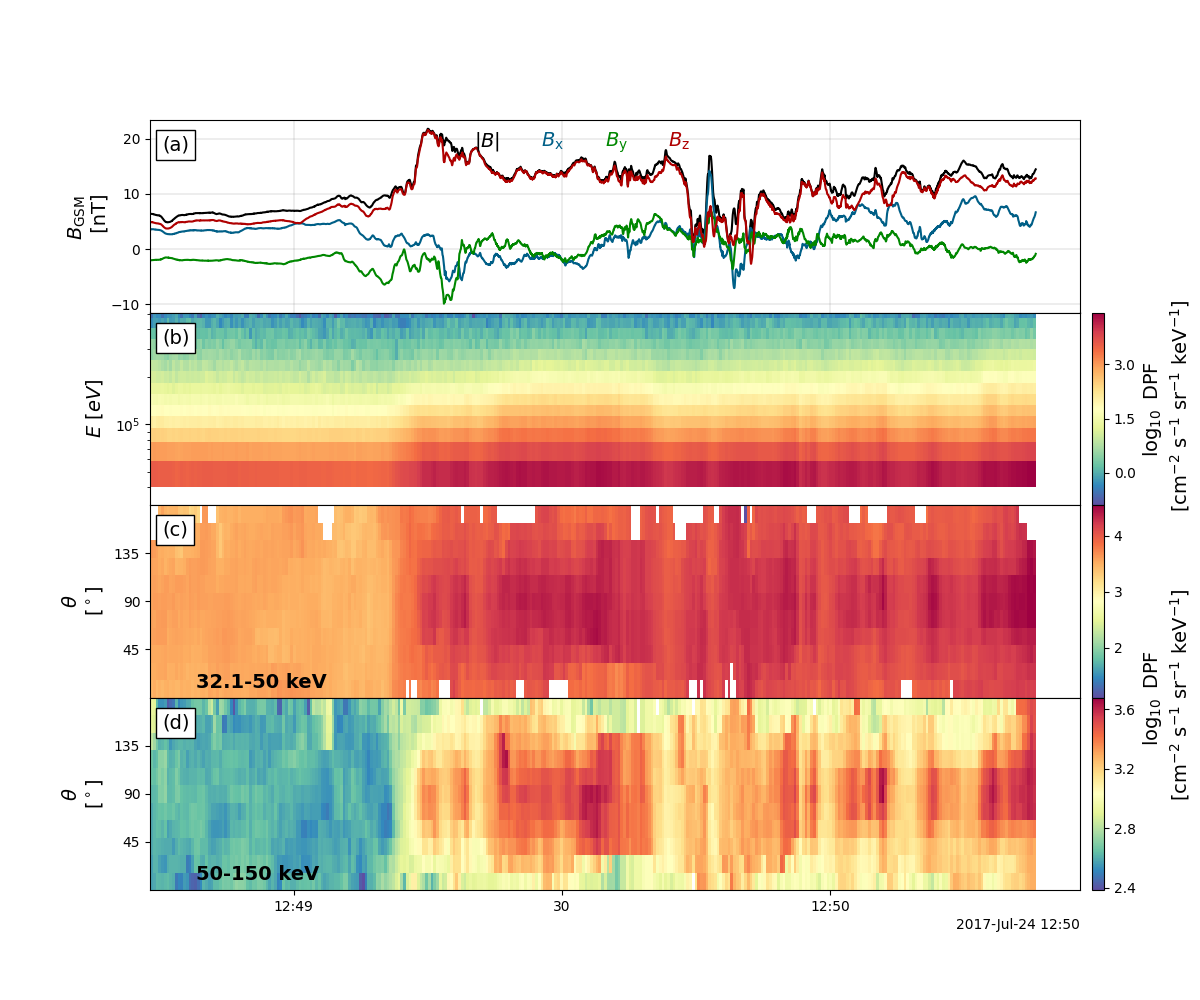

In [28]:
legend_options = dict(frameon=False, loc="upper right", fontsize = 14, handletextpad = 0.1)


fig, axs = plt.subplots(2 + len(energy_ranges),figsize=(12, 10), sharex="all")
fig.subplots_adjust(hspace=0.0)

plot_line(axs[0], pyrf.norm(b_gsm_4sc), color = "black", label = "$|B|$")
plot_line(axs[0], b_gsm_4sc, label = ["$B_{\mathrm{x}}$", "$B_{\mathrm{y}}$", "$B_{\mathrm{z}}$"])
axs[0].legend(**legend_options, labelcolor = "linecolor", bbox_to_anchor=(0.6, 1.04), handlelength = 0.0, ncols = 4, )
axs[0].set_ylabel("$B_{\mathrm{GSM}}$ \n [nT]", fontsize = 14, labelpad = 1)

axs[1], caxs = plot_spectr(axs[1], np.log10(dpf_feeps_omni_e_avg), cmap="Spectral_r", yscale="log")
caxs.set_ylabel("$\log_{10}$ DPF \n $[\mathrm{cm}^{-2} ~\mathrm{s}^{-1} ~\mathrm{sr}^{-1} ~\mathrm{keV}^{-1}]$", x = 1, y = 0.5, fontsize = 14)
axs[1].set_ylabel("$E$ [$eV$]", fontsize = 14)


for i_feeps in range(0, len(energy_ranges)):

    plot_id = 2 + i_feeps
    axs[plot_id], caxs = plot_spectr(axs[plot_id], np.log10(dpf_feeps_pad_4sc_enranges[i_feeps]),  cmap="Spectral_r",)

    axs[plot_id].set_ylabel("$\\theta$" + "\n" + "[$^\\circ$]", fontsize = 14)
    if i_feeps == 0 and (len(energy_ranges)  ) % 2 == 1:
        caxs.set_ylabel("$\log_{10}$ DPF \n $[\mathrm{cm}^{-2} ~\mathrm{s}^{-1} ~\mathrm{sr}^{-1} ~\mathrm{keV}^{-1}]$", fontsize = 14, x = 1, y = 0.5,
        )
    elif i_feeps == 1 and (len(energy_ranges) ) % 2 == 0:
        caxs.set_ylabel("$\log_{10}$ DPF \n $[\mathrm{cm}^{-2} ~\mathrm{s}^{-1} ~\mathrm{sr}^{-1} ~\mathrm{keV}^{-1}]$", fontsize = 14, x= 1, y = 1,
        )

    axs[plot_id].set_yticks([45, 90, 135])
    axs[plot_id].set_ylim([0, 180])
    axs[plot_id].text(0.05, 0.05, f"{energy_ranges[i_feeps][0]}-{energy_ranges[i_feeps][1]} keV", transform=axs[plot_id].transAxes, fontsize = 14, weight = "bold")

make_labels(axs, [0.013, 0.84], bbox=dict(facecolor='white', edgecolor='black',), fontsize = 14)

fig.align_ylabels(axs)